In [31]:
"""Example use of TurnTrim.solve_steady_level_turn."""

import sys
import os
import math

# ../bin/AnalysisVSPAERO.py をモジュールとしてインポート
sys.path.append(os.path.join('../..')) # 親ディレクトリをモジュール探索パスに追加
from src.TrimTurnSolver import solve_steady_gliding_turn


In [32]:

result = solve_steady_gliding_turn(
    fixed={
        "V": 10.0,          # m/s
        # "Omega": 0.08,     # rad/s
        "phi": math.radians(5.0),
        "delta_a": 0.0,
        # "T": 0.0,
        # "beta": math.radians(0.0),       # rad, coordinated turn condition
    },
    stab_path="../models/BRGlider/BRGlider.stab",
    mass=100.0,             # kg
    rho=1.225,              # kg/m^3
    initial_guess={
        "alpha": math.radians(0.0),
        # "phi": math.radians(15.0),
        "theta": math.radians(0.0),
    },
    verbose=1,
)

print("\nsolution")
for name, value in result["solution"].items():
    if name in {"alpha", "beta", "phi", "theta", "delta_e", "delta_a", "delta_r"}:
        print(f"{name:8s}: {value: .6f} rad = {math.degrees(value): .3f} deg")
    elif name in {"Omega",}:
        print(f"{name:8s}: {value: .6f} rad/s = {math.degrees(value): .3f} deg/s")
    elif name in {"V",}:
        print(f"{name:8s}: {value: .6f} m/s = {3.6*value: .3f} km/h")
    else:
        print(f"{name:8s}: {value: .6f}")

print("\nresiduals")
for name, value in result["residuals"].items():
    print(f"{name:8s}: {value: .6e}")


`gtol` termination condition is satisfied.
max_abs_residual = 1.540613e-09
sink_rate = 2.459884e-01

solution
V       :  10.000000 m/s =  36.000 km/h
phi     :  0.087266 rad =  5.000 deg
delta_a :  0.000000 rad =  0.000 deg
alpha   :  0.003920 rad =  0.225 deg
beta    :  0.166606 rad =  9.546 deg
theta   : -0.006383 rad = -0.366 deg
Omega   :  0.068113 rad/s =  3.903 deg/s
delta_e : -0.014676 rad = -0.841 deg
delta_r : -0.203930 rad = -11.684 deg
T       :  0.000000

residuals
force_x :  1.540613e-09
force_y :  5.896034e-10
force_z : -7.597374e-11
moment_l: -9.301661e-12
moment_m: -3.821745e-16
moment_n: -8.823244e-13


crosswind_gust_success                                   True
crosswind_gust_message                                       
crosswind_gust_Uds                                       -3.0
crosswind_gust_H                                        9.144
crosswind_gust_start_time                                 0.0
crosswind_gust_end_time                                1.8288
crosswind_gust_duration                                1.8288
crosswind_gust_reference_V                               10.0
crosswind_gust_beta_peak_input                           -0.3
crosswind_gust_phi0                                       0.0
crosswind_gust_t_start                                    0.0
crosswind_gust_t_final                                    6.0
crosswind_gust_phi_final                             0.004619
crosswind_gust_phi_delta_final                       0.004619
crosswind_gust_phi_delta_at_gust_end                -0.016567
crosswind_gust_max_phi_delta                        -0.019938
crosswin

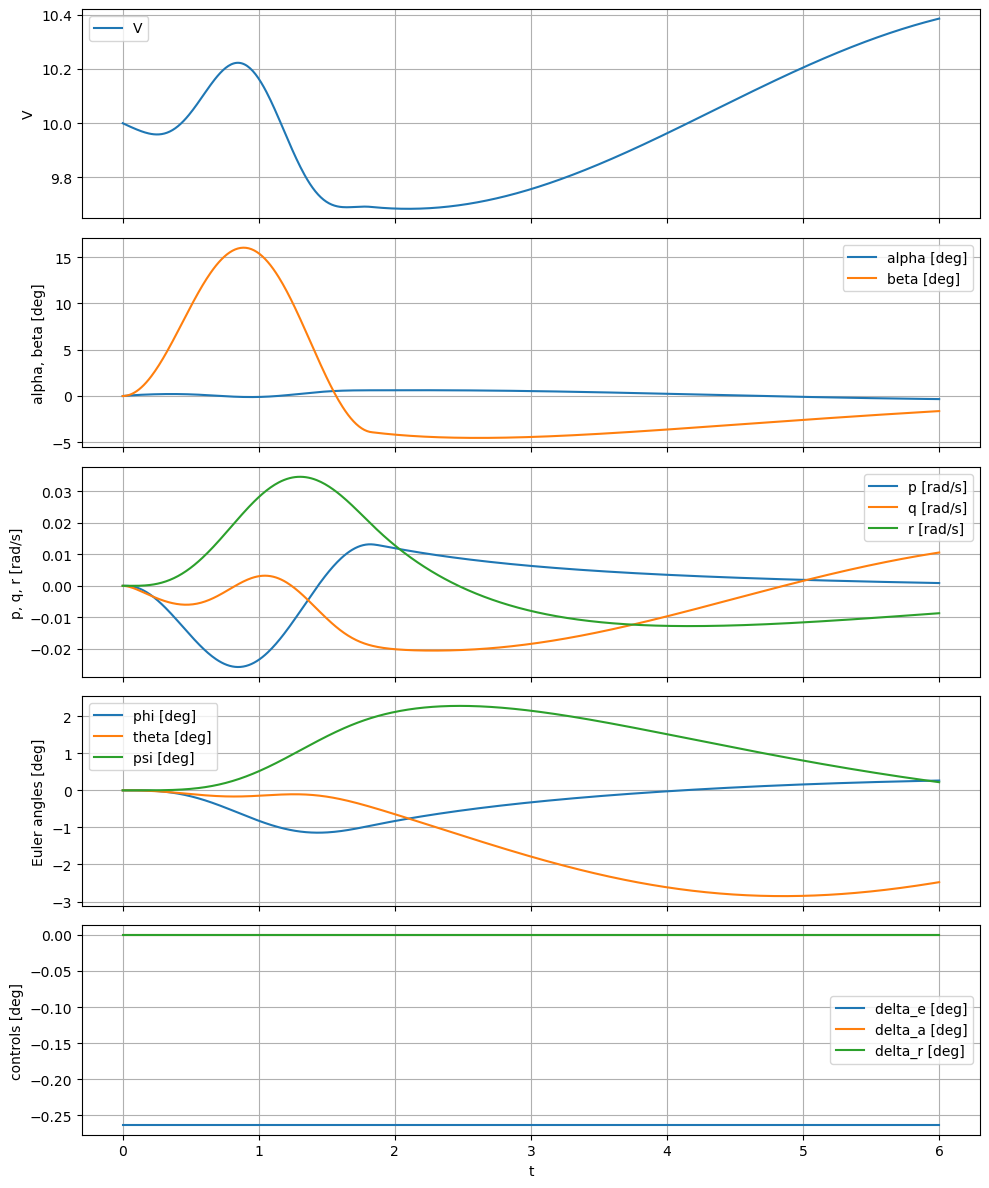

In [33]:
import math
import pandas as pd

from src.RollRudderGain import (
    simulate_6dof_crosswind_gust_from_stab,
    calculate_crosswind_gust_response_metrics,
    write_6dof_history_csv,
    plot_6dof_history,
)

# stab_path = "../models/G103A/G103A.stab"
stab_path = "../models/BRGlider/BRGlider.stab"

mass = 100.0
inertia = {
    "Ixx": 1000.0,
    "Iyy": 75.0,
    "Izz": 1100.0,
    "Ixz": 0.0,
}

# .stab の Vinf が m/s なら、Uds も m/s、H も m でそろえる
Uds = -3.0          # 設計突風速度 [m/s]
H = 9.144         # 突風勾配距離 [m] = 30 ft

history = simulate_6dof_crosswind_gust_from_stab(
    stab_path,
    mass=mass,
    Ixx=inertia["Ixx"],
    Iyy=inertia["Iyy"],
    Izz=inertia["Izz"],
    Ixz=inertia["Ixz"],
    Uds=Uds,
    H=H,
    t_final=6.0,
    delta_a=0.0,
    delta_r=0.0,
    delta_e=None,
    trim_elevator=True,
    trim_thrust=False,
    phi0=0.0,
    theta0=None,
    psi0=0.0,
    gust_start_time=0.0,
    max_step=0.01,
)

metrics = calculate_crosswind_gust_response_metrics(history)

print(pd.Series(metrics))

write_6dof_history_csv(
    history,
    "./results/crosswind_gust_6dof_history.csv",
)

plot_6dof_history(
    history,
    plot_path="./results/crosswind_gust_6dof_history.png",
    show=False,
    degrees=True,
)

crosswind_gust_success                                   True
crosswind_gust_message                                       
crosswind_gust_Uds                                       -3.0
crosswind_gust_H                                        9.144
crosswind_gust_start_time                                 0.0
crosswind_gust_end_time                                1.8288
crosswind_gust_duration                                1.8288
crosswind_gust_reference_V                               10.0
crosswind_gust_beta_peak_input                           -0.3
crosswind_gust_phi0                                       0.0
crosswind_gust_t_start                                    0.0
crosswind_gust_t_final                                    6.0
crosswind_gust_phi_final                             0.004619
crosswind_gust_phi_delta_final                       0.004619
crosswind_gust_phi_delta_at_gust_end                -0.016567
crosswind_gust_max_phi_delta                        -0.019938
crosswin

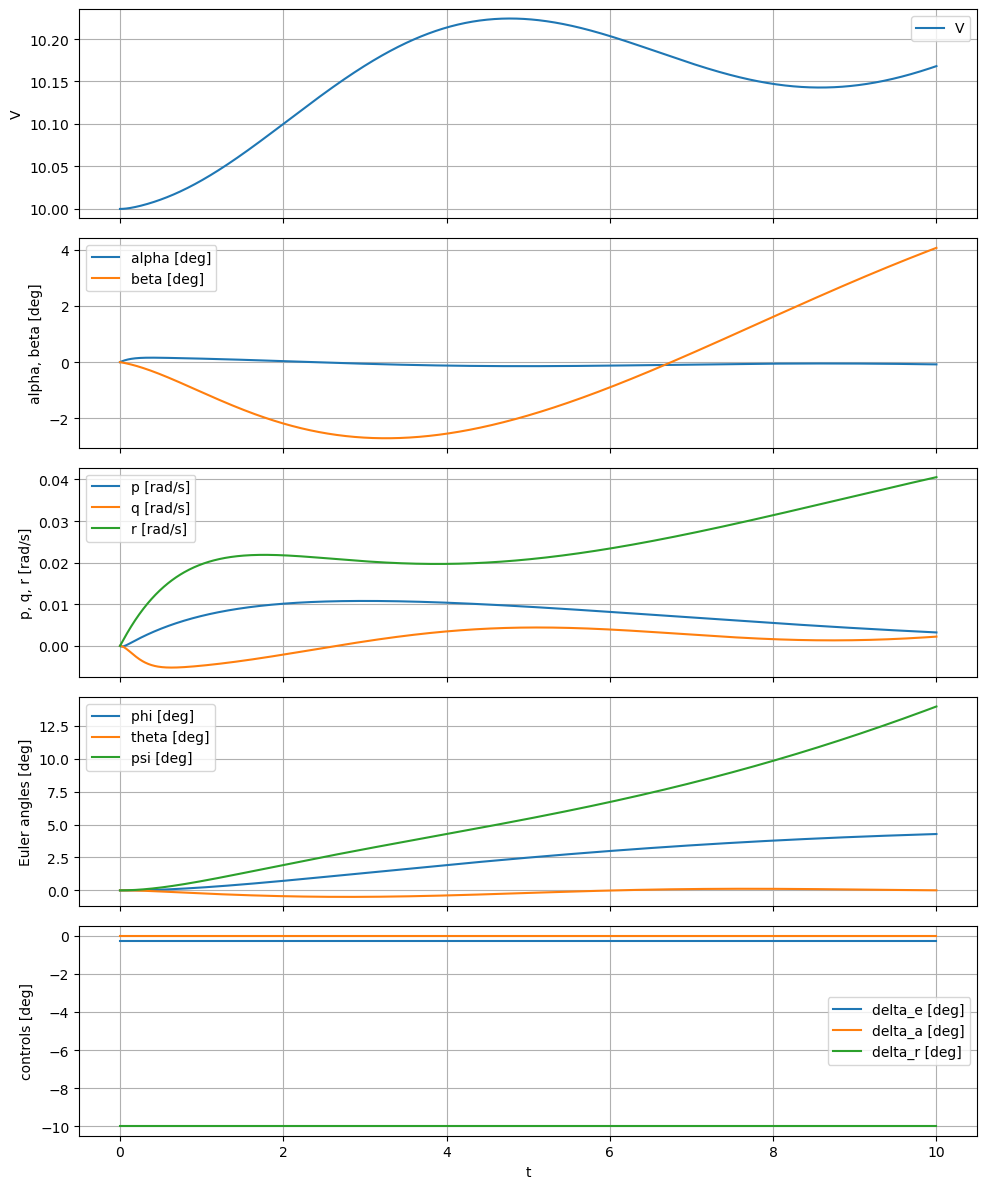

In [36]:
import math

from src.RollRudderGain import (
    simulate_6dof_rudder_step_from_stab,
    calculate_roll_response_metric_by_delta_phi,
)

delta_r = math.radians(-10.0)
target_delta_phi = math.radians(5.0)

history = simulate_6dof_rudder_step_from_stab(
    stab_path,
    mass=mass,
    Ixx=inertia["Ixx"],
    Iyy=inertia["Iyy"],
    Izz=inertia["Izz"],
    Ixz=inertia["Ixz"],
    delta_r=delta_r,
    t_final=10.0,
    max_step=0.01,
)

metric = calculate_roll_response_metric_by_delta_phi(
    history,
    delta_r=delta_r,
    target_delta_phi=target_delta_phi,
    V=10,
    Bref=27,
    phi0=0.0,
)

print(pd.Series(metrics))

write_6dof_history_csv(
    history,
    "./results/rudder_roll_6dof_history.csv",
)

plot_6dof_history(
    history,
    plot_path="./results/rudder_roll_6dof_history.png",
    show=False,
    degrees=True,
)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from src.RollRudderGain import one_cosine_gust_velocity

Uds = 5.0
H = 9.144
V = 30.0

t_end = 2.0 * H / V
t = np.linspace(0.0, 1.5 * t_end, 300)

vg = [
    one_cosine_gust_velocity(ti, Uds=Uds, H=H, V=V)
    for ti in t
]

plt.figure()
plt.plot(t, vg)
plt.xlabel("time [s]")
plt.ylabel("gust velocity v_g [m/s]")
plt.grid(True)
plt.show()

In [ ]:
# V       :  30.000000 m/s =  108.000 km/h
# phi     :  0.523599 rad =  30.000 deg
# beta    :  0.174533 rad =  10.000 deg
# alpha   :  0.059222 rad =  3.393 deg
# theta   :  0.138768 rad =  7.951 deg
# Omega   :  0.184166 rad/s =  10.552 deg/s
# delta_e :  0.000048 rad =  0.003 deg
# delta_a : -0.006328 rad = -0.363 deg
# delta_r : -0.001422 rad = -0.081 deg
# T       :  181.069516

# V       :  30.000000 m/s =  108.000 km/h
# phi     :  0.523599 rad =  30.000 deg
# beta    : -0.174533 rad = -10.000 deg
# alpha   :  0.063237 rad =  3.623 deg
# theta   : -0.033489 rad = -1.919 deg
# Omega   :  0.200343 rad/s =  11.479 deg/s
# delta_e : -0.152460 rad = -8.735 deg
# delta_a :  0.048606 rad =  2.785 deg
# delta_r :  0.103778 rad =  5.946 deg
# T       :  197.030667
